In [1]:
import pypsa

n = pypsa.Network()


Creates a simple network with 3 generators on two buses with a transmission loss of 7%

In [2]:
# add bus 
# n.add("Bus", "bus1")
# n.add("Bus", "bus2")
n.add("Bus", "bus1", v_nom=110)
n.add("Bus", "bus2", v_nom=110)

# add load
n.add("Load", "Demand", bus="bus1", p_set=500)

# add generator
n.add("Generator", "coal_gen", bus="bus2", p_nom=100, p_nom_min=50, marginal_cost=3)
n.add("Generator", "gas_gen", bus="bus2", p_nom=400, p_nom_min=300, marginal_cost=4)    
n.add("Generator", "wind_gen", bus="bus2", p_nom=100, p_nom_min=0, marginal_cost=0)

# add line to create topology
# n.add("Line", "line1", bus0="bus1", bus1="bus2", s_nom=1000, x=0.4)
n.add("Line", "line1", bus0="bus1", bus1="bus2", r=(0.07*(110**2)/1000), s_nom=1000, x=0.4)

In [3]:
# Optimize the network
n.optimize()

Index(['bus1', 'bus2'], dtype='object', name='Bus')
Index(['line1'], dtype='object', name='Line')
Index(['bus1', 'bus2'], dtype='object', name='Bus')
Index(['line1'], dtype='object', name='Line')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.01s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 4 primals, 10 duals
Objective: 1.50e+03
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Line-fix-s-lower, Line-fix-s-upper were not assigned to the network.


Running HiGHS 1.11.0 (git hash: n/a): Copyright (c) 2025 HiGHS under MIT licence terms
LP   linopy-problem-_kccl0b0 has 10 rows; 4 cols; 13 nonzeros
Coefficient ranges:
  Matrix [1e+00, 1e+00]
  Cost   [3e+00, 4e+00]
  Bound  [0e+00, 0e+00]
  RHS    [1e+02, 1e+03]
Presolving model
1 rows, 2 cols, 2 nonzeros  0s
0 rows, 0 cols, 0 nonzeros  0s
Presolve : Reductions: rows 0(-10); columns 0(-4); elements 0(-13) - Reduced to empty
Solving the original LP from the solution after postsolve
Model name          : linopy-problem-_kccl0b0
Model status        : Optimal
Objective value     :  1.5000000000e+03
P-D objective error :  0.0000000000e+00
HiGHS run time      :          0.00
Writing the solution to /tmp/linopy-solve-qvp6g7pv.sol


('ok', 'optimal')

In [4]:
n.model.to_file("economic_dispatch_pypsa.lp")

INFO:linopy.io: Writing time: 0.03s


PosixPath('economic_dispatch_pypsa.lp')

In [5]:
n.explore

<bound method explore of PyPSA Network
Components:
 - Bus: 2
 - Generator: 3
 - Line: 1
 - Load: 1
 - SubNetwork: 1
Snapshots: 1>

/home/mwiche/anaconda3/envs/pypsa-earth/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/mwiche/anaconda3/envs/pypsa-earth/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:842: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  self.set_ylim([y1, y2])


(<matplotlib.collections.PatchCollection at 0x7b4fe99dea90>,
 <matplotlib.collections.LineCollection at 0x7b513aaf2550>)

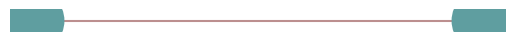

In [6]:
n.plot()

In [7]:
n.pf()

INFO:pypsa.pf:Performing non-linear load-flow on AC sub-network SubNetwork 0 for snapshots Index(['now'], dtype='object', name='snapshot')
INFO:pypsa.pf:Newton-Raphson solved in 3 iterations with error of 0.000000 in 0.014377 seconds


{'n_iter': SubNetwork  0
 snapshot     
 now         3,
 'error': SubNetwork             0
 snapshot                
 now         9.417499e-08,
 'converged': SubNetwork     0
 snapshot        
 now         True}